<a href="https://colab.research.google.com/github/GhostRyn/Machine-Learning-Customer-Propensit-End-to-end./blob/main/Customer_Propensity_ML_Pipeline_KEL_6__FIX.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛒 Customer Propensity to Purchase
## End-to-End Machine Learning Pipeline

**Dataset:** E-Commerce Behavioral Clickstream Data  
**Task:** Binary Classification — Prediksi apakah user akan melakukan pembelian (`ordered = 1`)  
**Metrik Utama:** ROC-AUC, F1-Score (karena class imbalance)

---
| Info | Detail |
|------|--------|
| Training Set | 455.401 baris × 25 kolom |
| Testing Set  | 151.655 baris (unlabeled — untuk prediksi akhir) |
| Target | `ordered` (0 = tidak beli, 1 = beli) |
| Class Ratio | ~95.8% : 4.2% (imbalanced) |


In [1]:
# ── Install Dependencies
# !pip install imbalanced-learn xgboost scikit-learn pandas numpy matplotlib seaborn -q

# ── Imports ──
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import pickle
import os

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, roc_curve, classification_report,
    confusion_matrix, f1_score, precision_score, recall_score,
    ConfusionMatrixDisplay, precision_recall_curve, average_precision_score
)
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')

print("✅ Semua library berhasil di-import!")
print(f"   Pandas    : {pd.__version__}")
print(f"   Numpy     : {np.__version__}")


✅ Semua library berhasil di-import!
   Pandas    : 2.2.2
   Numpy     : 2.0.2


## 1. 📂 Load Dataset

In [2]:
# ── Load Dataset ──


TRAIN_PATH = 'training_sample.csv'
TEST_PATH  = 'testing_sample.csv'

train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

print(f"📊 Training Set : {train_df.shape[0]:,} baris × {train_df.shape[1]} kolom")
print(f"📊 Testing Set  : {test_df.shape[0]:,} baris × {test_df.shape[1]} kolom")
print()
print("Kolom Training:")
print(list(train_df.columns))
train_df.head()


📊 Training Set : 455,401 baris × 25 kolom
📊 Testing Set  : 151,655 baris × 25 kolom

Kolom Training:
['UserID', 'basket_icon_click', 'basket_add_list', 'basket_add_detail', 'sort_by', 'image_picker', 'account_page_click', 'promo_banner_click', 'detail_wishlist_add', 'list_size_dropdown', 'closed_minibasket_click', 'checked_delivery_detail', 'checked_returns_detail', 'sign_in', 'saw_checkout', 'saw_sizecharts', 'saw_delivery', 'saw_account_upgrade', 'saw_homepage', 'device_mobile', 'device_computer', 'device_tablet', 'returning_user', 'loc_uk', 'ordered']


,UserID,basket_icon_click,basket_add_list,basket_add_detail,sort_by,image_picker,account_page_click,promo_banner_click,detail_wishlist_add,list_size_dropdown,...,saw_sizecharts,saw_delivery,saw_account_upgrade,saw_homepage,device_mobile,device_computer,device_tablet,returning_user,loc_uk,ordered
0,a720-6b732349-a720-4862-bd21-644732,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
1,a0c0-6b73247c-a0c0-4bd9-8baa-797356,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
2,86a8-6b735c67-86a8-407b-ba24-333055,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,1,1,0
3,6a3d-6b736346-6a3d-4085-934b-396834,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,1,1,0
4,b74a-6b737717-b74a-45c3-8c6a-421140,0,1,0,1,0,0,0,0,1,...,0,0,0,1,0,0,1,0,1,1


## 2. 🔍 Exploratory Data Analysis (EDA)

In [3]:
# ── 2.1 Informasi Umum Dataset ──
print("=" * 55)
print("TRAINING SET — INFO")
print("=" * 55)
train_df.info()
print()
print("=" * 55)
print("STATISTIK DESKRIPTIF")
print("=" * 55)
train_df.describe().T


TRAINING SET — INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 455401 entries, 0 to 455400
Data columns (total 25 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   UserID                   455401 non-null  object
 1   basket_icon_click        455401 non-null  int64 
 2   basket_add_list          455401 non-null  int64 
 3   basket_add_detail        455401 non-null  int64 
 4   sort_by                  455401 non-null  int64 
 5   image_picker             455401 non-null  int64 
 6   account_page_click       455401 non-null  int64 
 7   promo_banner_click       455401 non-null  int64 
 8   detail_wishlist_add      455401 non-null  int64 
 9   list_size_dropdown       455401 non-null  int64 
 10  closed_minibasket_click  455401 non-null  int64 
 11  checked_delivery_detail  455401 non-null  int64 
 12  checked_returns_detail   455401 non-null  int64 
 13  sign_in                  455401 non-null  int64 
 14  

,count,mean,std,min,25%,50%,75%,max
basket_icon_click,455401.0,0.099150,0.298864,0.0,0.0,0.0,0.0,1.0
basket_add_list,455401.0,0.074521,0.262617,0.0,0.0,0.0,0.0,1.0
basket_add_detail,455401.0,0.112916,0.316490,0.0,0.0,0.0,0.0,1.0
sort_by,455401.0,0.036849,0.188391,0.0,0.0,0.0,0.0,1.0
image_picker,455401.0,0.026735,0.161307,0.0,0.0,0.0,0.0,1.0
account_page_click,455401.0,0.003570,0.059647,0.0,0.0,0.0,0.0,1.0
promo_banner_click,455401.0,0.016208,0.126274,0.0,0.0,0.0,0.0,1.0
detail_wishlist_add,455401.0,0.003511,0.059151,0.0,0.0,0.0,0.0,1.0
list_size_dropdown,455401.0,0.230362,0.421065,0.0,0.0,0.0,0.0,1.0
closed_minibasket_click,455401.0,0.017277,0.130302,0.0,0.0,0.0,0.0,1.0


In [4]:
# ── 2.2 Missing Values ──
print("=" * 40)
print("MISSING VALUES — TRAINING")
print("=" * 40)
missing = train_df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "✅ Tidak ada missing value!")

print()
print("=" * 40)
print("MISSING VALUES — TESTING")
print("=" * 40)
missing_test = test_df.isnull().sum()
print(missing_test[missing_test > 0] if missing_test.sum() > 0 else "✅ Tidak ada missing value!")


MISSING VALUES — TRAINING
✅ Tidak ada missing value!

MISSING VALUES — TESTING
✅ Tidak ada missing value!


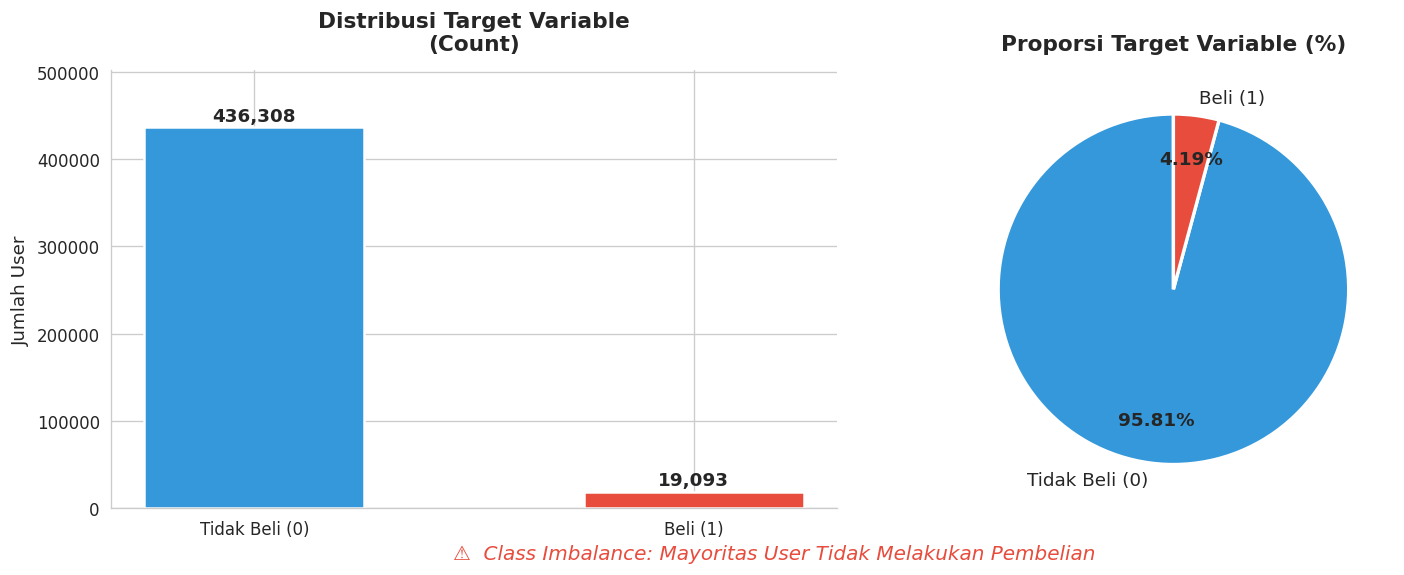


Rasio Class:
  Tidak Beli : 95.81%
  Beli       : 4.19%


In [5]:
# ── 2.3 Distribusi Target Variable ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1 — Count
ordered_counts = train_df['ordered'].value_counts()
colors = ['#3498DB', '#E74C3C']
bars = axes[0].bar(['Tidak Beli (0)', 'Beli (1)'], ordered_counts.values, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
axes[0].set_title('Distribusi Target Variable\n(Count)', fontsize=13, fontweight='bold', pad=12)
axes[0].set_ylabel('Jumlah User', fontsize=11)
for bar, val in zip(bars, ordered_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3000,
                 f'{val:,}', ha='center', va='bottom', fontweight='bold', fontsize=11)
axes[0].set_ylim(0, ordered_counts.max() * 1.15)
axes[0].spines[['top','right']].set_visible(False)

# Plot 2 — Pie
pct = train_df['ordered'].value_counts(normalize=True) * 100
wedges, texts, autotexts = axes[1].pie(
    pct.values, labels=['Tidak Beli (0)', 'Beli (1)'],
    colors=colors, autopct='%1.2f%%', startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2), pctdistance=0.75,
    textprops={'fontsize': 11}
)
for at in autotexts:
    at.set_fontweight('bold')
axes[1].set_title('Proporsi Target Variable (%)', fontsize=13, fontweight='bold', pad=12)

plt.suptitle('⚠️  Class Imbalance: Mayoritas User Tidak Melakukan Pembelian',
             fontsize=12, style='italic', color='#E74C3C', y=0.02)
plt.tight_layout()
plt.savefig('plot_target_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print(f"\nRasio Class:\n  Tidak Beli : {pct[0]:.2f}%\n  Beli       : {pct[1]:.2f}%")


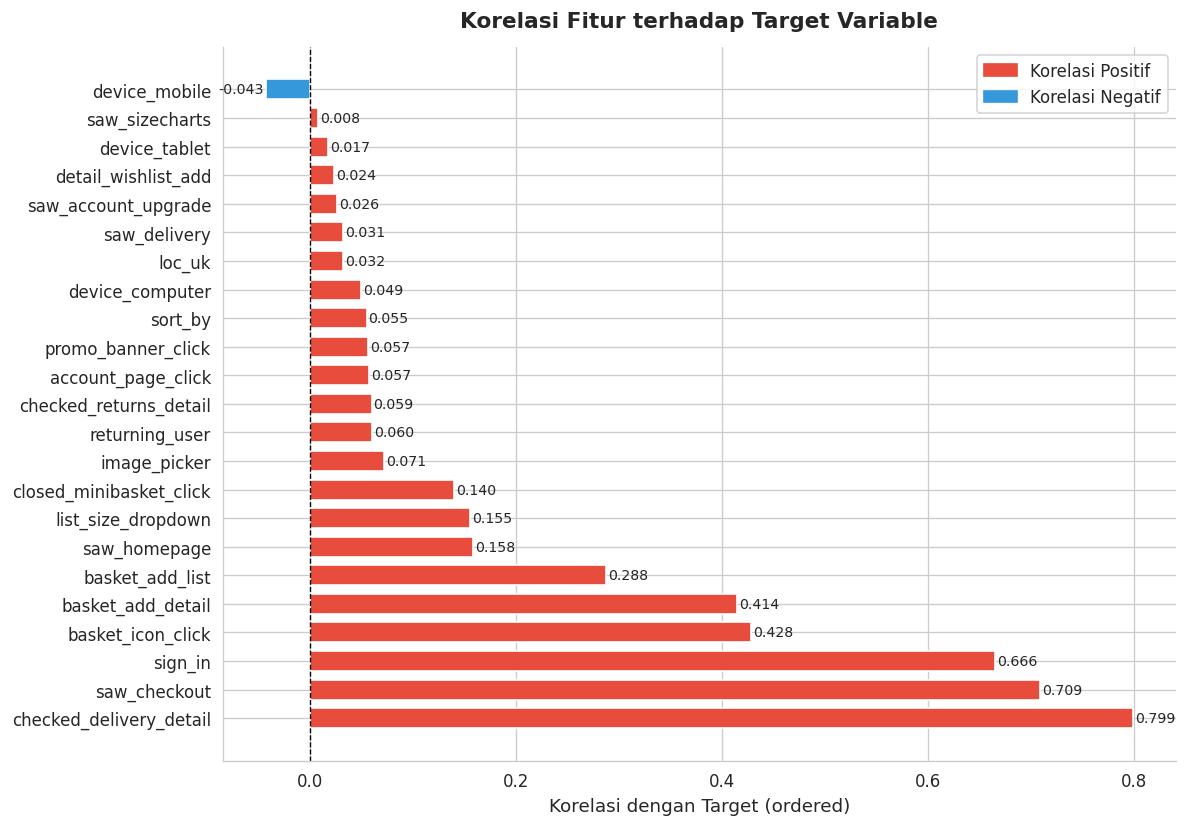


Top 5 Fitur Berkorelasi Positif:
checked_delivery_detail    0.798720
saw_checkout               0.708986
sign_in                    0.665556
basket_icon_click          0.428334
basket_add_detail          0.414420

Top 5 Fitur Berkorelasi Negatif:
saw_account_upgrade    0.025857
detail_wishlist_add    0.023516
device_tablet          0.016939
saw_sizecharts         0.007548
device_mobile         -0.042907


In [6]:
# ── 2.4 Feature Correlation dengan Target ──
feature_cols = [c for c in train_df.columns if c not in ['UserID', 'ordered']]

corr = train_df[feature_cols + ['ordered']].corr()['ordered'].drop('ordered').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
colors_bar = ['#E74C3C' if v > 0 else '#3498DB' for v in corr.values]
bars = ax.barh(corr.index, corr.values, color=colors_bar, edgecolor='white', height=0.7)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Korelasi dengan Target (ordered)', fontsize=11)
ax.set_title('Korelasi Fitur terhadap Target Variable', fontsize=13, fontweight='bold', pad=12)
for bar, val in zip(bars, corr.values):
    ax.text(val + (0.002 if val >= 0 else -0.002), bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=8.5)
ax.spines[['top','right']].set_visible(False)
red_patch = mpatches.Patch(color='#E74C3C', label='Korelasi Positif')
blue_patch = mpatches.Patch(color='#3498DB', label='Korelasi Negatif')
ax.legend(handles=[red_patch, blue_patch], fontsize=10)
plt.tight_layout()
plt.savefig('plot_feature_correlation.png', bbox_inches='tight', dpi=150)
plt.show()

print("\nTop 5 Fitur Berkorelasi Positif:")
print(corr.head(5).to_string())
print("\nTop 5 Fitur Berkorelasi Negatif:")
print(corr.tail(5).to_string())


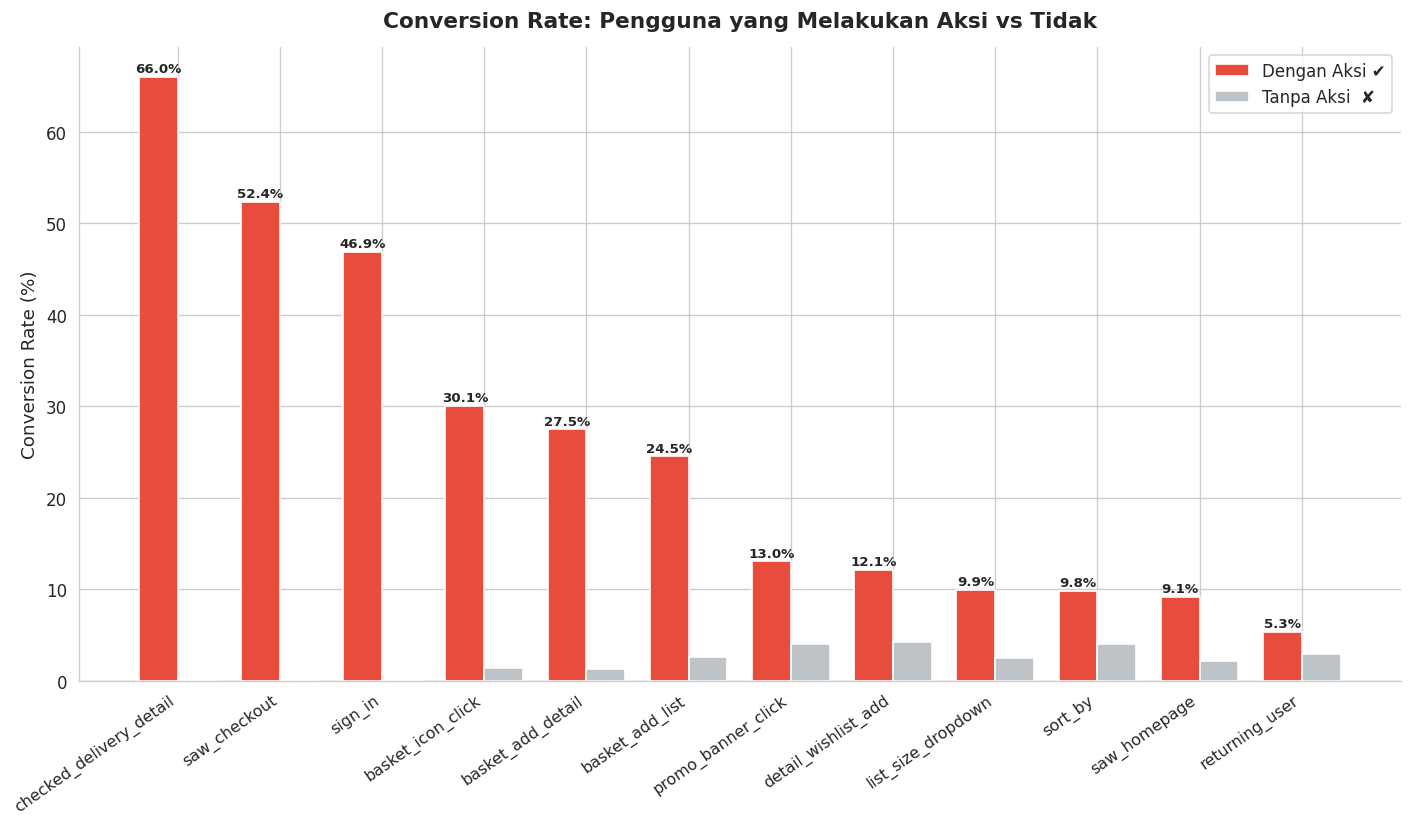

In [7]:
# ── 2.5 Konversi Rate per Fitur ──
behavioral_cols = [
    'basket_icon_click','basket_add_list','basket_add_detail',
    'saw_checkout','sign_in','checked_delivery_detail',
    'list_size_dropdown','saw_homepage','returning_user',
    'promo_banner_click','detail_wishlist_add','sort_by'
]

conv_rates = {}
for col in behavioral_cols:
    users_with_action    = train_df[train_df[col] == 1]['ordered'].mean() * 100
    users_without_action = train_df[train_df[col] == 0]['ordered'].mean() * 100
    conv_rates[col] = {'Dengan Aksi': users_with_action, 'Tanpa Aksi': users_without_action}

conv_df = pd.DataFrame(conv_rates).T.sort_values('Dengan Aksi', ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))
x = np.arange(len(conv_df))
w = 0.38
b1 = ax.bar(x - w/2, conv_df['Dengan Aksi'], w, label='Dengan Aksi ✔', color='#E74C3C', edgecolor='white')
b2 = ax.bar(x + w/2, conv_df['Tanpa Aksi'],  w, label='Tanpa Aksi  ✘', color='#BDC3C7', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(conv_df.index, rotation=35, ha='right', fontsize=9.5)
ax.set_ylabel('Conversion Rate (%)', fontsize=11)
ax.set_title('Conversion Rate: Pengguna yang Melakukan Aksi vs Tidak', fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=10)
ax.spines[['top','right']].set_visible(False)
for bar in b1:
    if bar.get_height() > 0.5:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_conversion_rate.png', bbox_inches='tight', dpi=150)
plt.show()


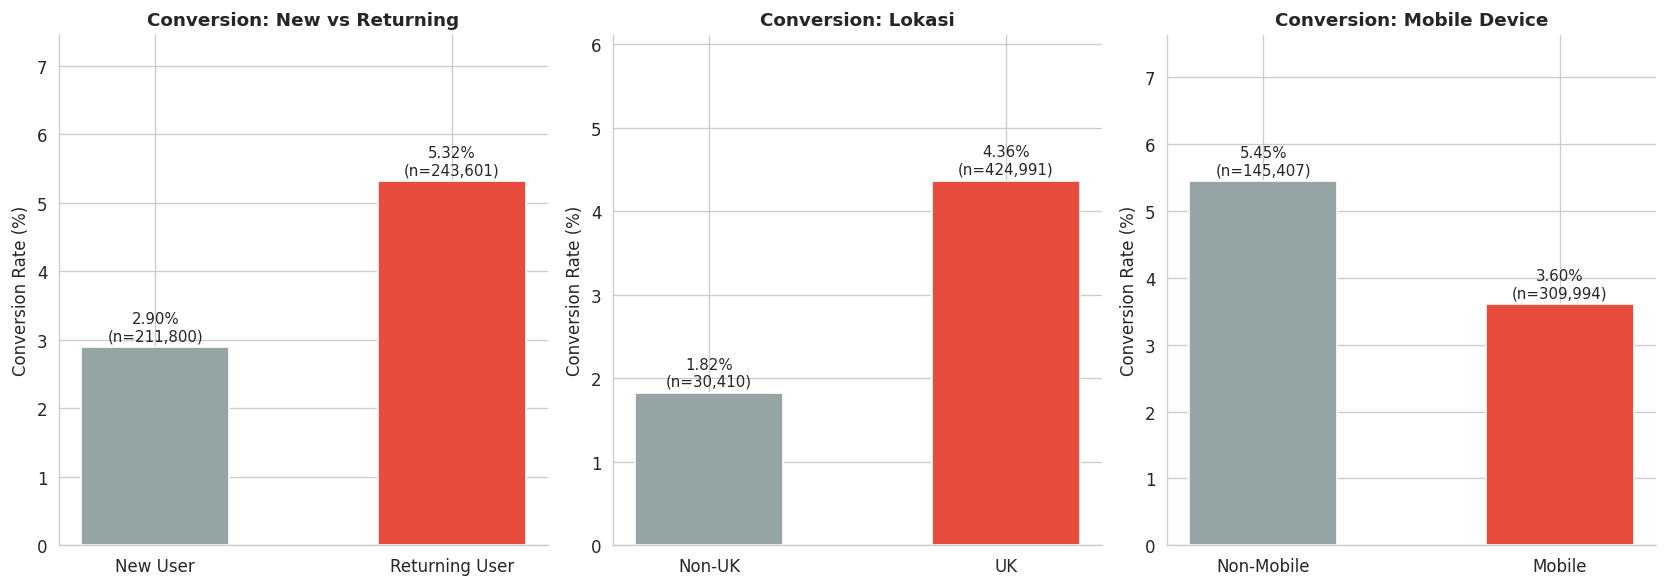

In [8]:
# ── 2.6 Device & User Type Analysis ──
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

def plot_group_conv(ax, group_col, labels, title):
    rates, counts = [], []
    for val in [0, 1]:
        sub = train_df[train_df[group_col] == val]
        rates.append(sub['ordered'].mean() * 100)
        counts.append(len(sub))
    colors_g = ['#95A5A6', '#E74C3C']
    bars = ax.bar(labels, rates, color=colors_g, edgecolor='white', width=0.5)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('Conversion Rate (%)')
    for bar, rate, cnt in zip(bars, rates, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{rate:.2f}%\n(n={cnt:,})', ha='center', va='bottom', fontsize=9)
    ax.set_ylim(0, max(rates) * 1.4)
    ax.spines[['top','right']].set_visible(False)

plot_group_conv(axes[0], 'returning_user', ['New User', 'Returning User'], 'Conversion: New vs Returning')
plot_group_conv(axes[1], 'loc_uk', ['Non-UK', 'UK'], 'Conversion: Lokasi')
plot_group_conv(axes[2], 'device_mobile', ['Non-Mobile', 'Mobile'], 'Conversion: Mobile Device')

plt.tight_layout()
plt.savefig('plot_group_analysis.png', bbox_inches='tight', dpi=150)
plt.show()


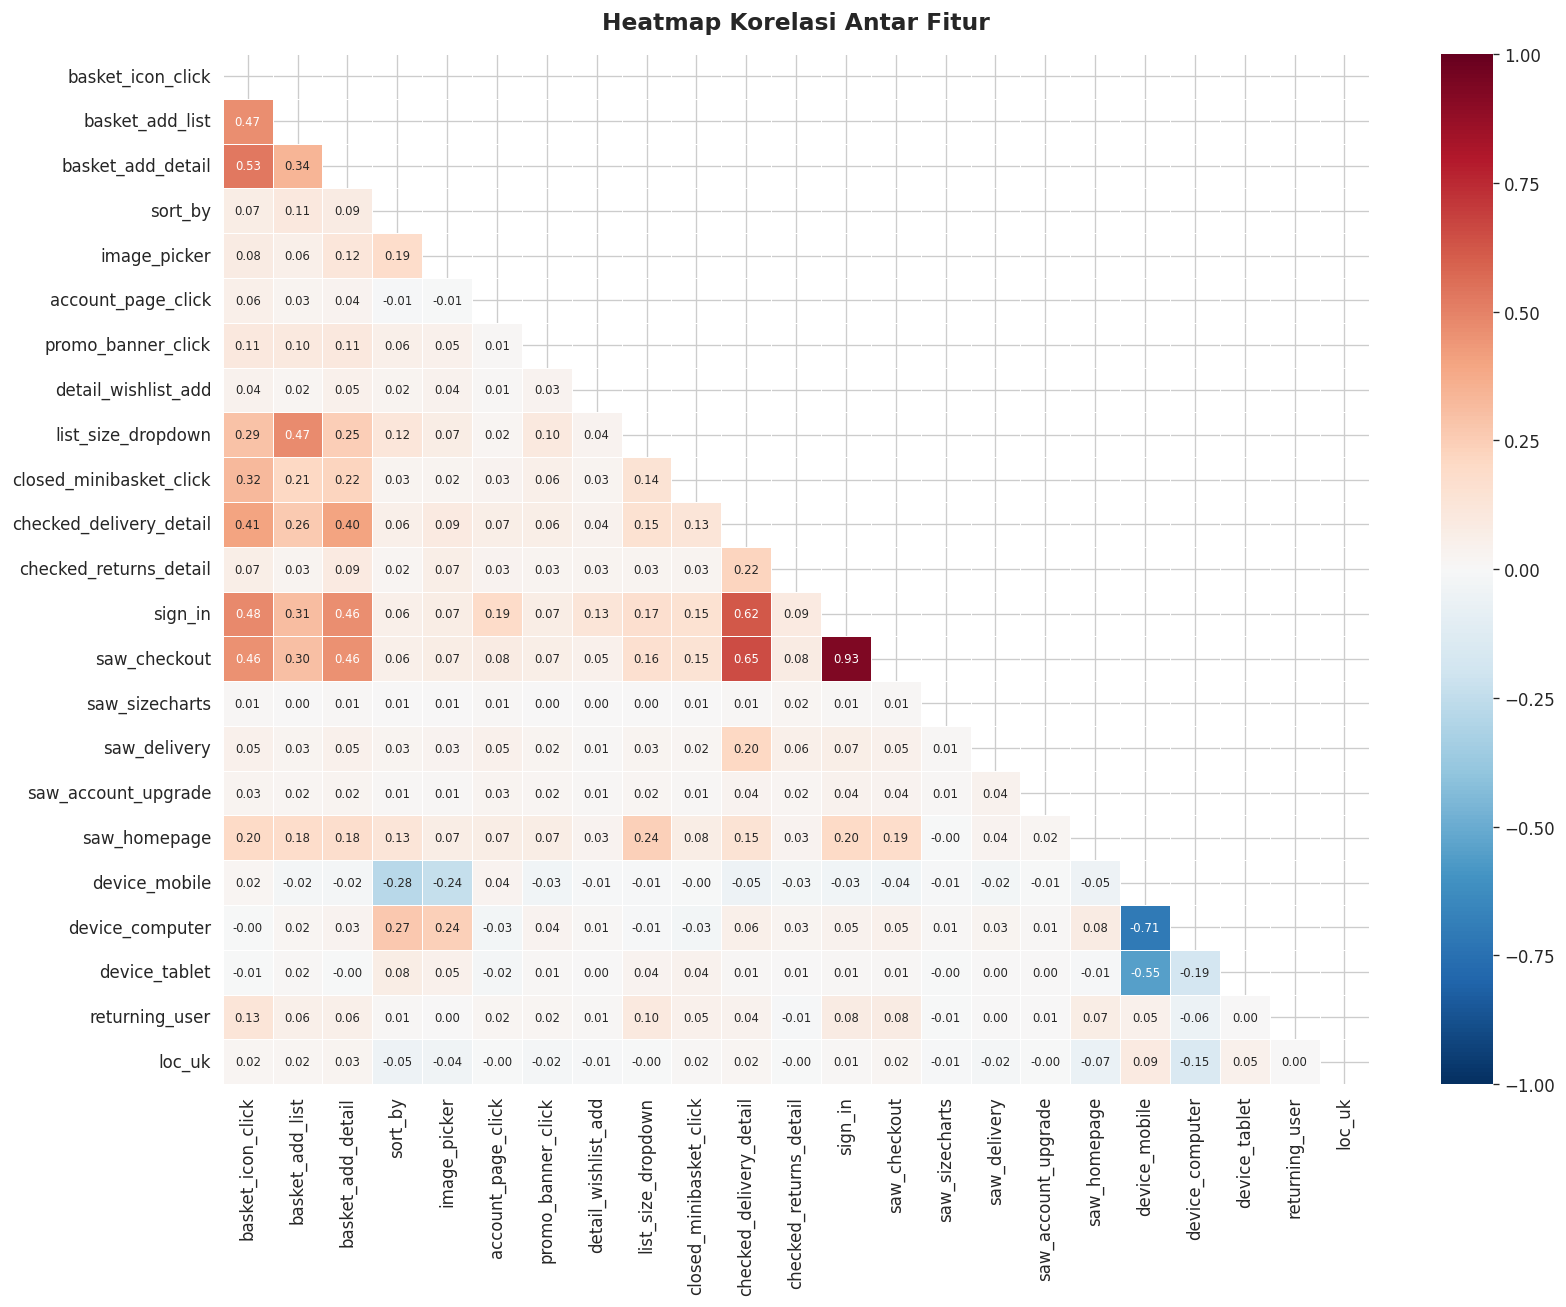

In [9]:
# ── 2.7 Heatmap Korelasi Antar Fitur ──
fig, ax = plt.subplots(figsize=(14, 11))
corr_matrix = train_df[feature_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, linewidths=0.5,
    annot_kws={'size': 7}, ax=ax,
    vmin=-1, vmax=1
)
ax.set_title('Heatmap Korelasi Antar Fitur', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('plot_heatmap_correlation.png', bbox_inches='tight', dpi=150)
plt.show()


## 3. ⚙️ Preprocessing & Feature Engineering

In [10]:
# ── 3.1 Definisi Fitur ──
feature_cols = [c for c in train_df.columns if c not in ['UserID', 'ordered']]

print(f"✅ Total fitur: {len(feature_cols)}")
print(f"   Fitur: {feature_cols}")
print()

# Semua fitur sudah binary (0/1) — tidak perlu encoding
# Tidak ada missing value — tidak perlu imputation
# Scaling hanya untuk Logistic Regression

X            = train_df[feature_cols].copy().reset_index(drop=True)
y            = train_df['ordered'].copy().reset_index(drop=True)
X_final_test = test_df[feature_cols].copy().reset_index(drop=True)

print(f"X shape        : {X.shape}")
print(f"y shape        : {y.shape}")
print(f"X_test shape   : {X_final_test.shape}")
print(f"\nDistribusi target:\n{y.value_counts().to_string()}")


✅ Total fitur: 23
   Fitur: ['basket_icon_click', 'basket_add_list', 'basket_add_detail', 'sort_by', 'image_picker', 'account_page_click', 'promo_banner_click', 'detail_wishlist_add', 'list_size_dropdown', 'closed_minibasket_click', 'checked_delivery_detail', 'checked_returns_detail', 'sign_in', 'saw_checkout', 'saw_sizecharts', 'saw_delivery', 'saw_account_upgrade', 'saw_homepage', 'device_mobile', 'device_computer', 'device_tablet', 'returning_user', 'loc_uk']

X shape        : (455401, 23)
y shape        : (455401,)
X_test shape   : (151655, 23)

Distribusi target:
ordered
0    436308
1     19093


In [11]:
# ── 3.2 Feature Engineering — Composite Features ──
def add_engineered_features(df):
    df = df.copy()
    # Purchase Intent Score — aksi yang sangat berkorelasi dengan pembelian
    df['purchase_intent_score'] = (
        df['basket_add_detail'] +
        df['basket_add_list'] +
        df['saw_checkout'] +
        df['basket_icon_click'] +
        df['sign_in']
    )
    # Engagement Score — keterlibatan umum dengan website
    df['engagement_score'] = (
        df['list_size_dropdown'] +
        df['checked_delivery_detail'] +
        df['image_picker'] +
        df['sort_by'] +
        df['promo_banner_click']
    )
    # Wishlist & Research — riset sebelum beli
    df['research_score'] = (
        df['detail_wishlist_add'] +
        df['checked_delivery_detail'] +
        df['checked_returns_detail'] +
        df['saw_sizecharts'] +
        df['saw_delivery']
    )
    # Total interaksi
    base_cols = [c for c in df.columns if c not in
                 ['purchase_intent_score','engagement_score','research_score']]
    binary_feature_cols = [c for c in base_cols if df[c].isin([0,1]).all()]
    df['total_interactions'] = df[binary_feature_cols].sum(axis=1)
    return df.reset_index(drop=True)

X_eng        = add_engineered_features(X)
X_te_eng     = add_engineered_features(X_final_test)
feature_cols_eng = X_eng.columns.tolist()

print(f"✅ Fitur setelah feature engineering: {len(feature_cols_eng)}")
print(f"   Fitur baru: purchase_intent_score, engagement_score, research_score, total_interactions")
print(f"   X_eng shape: {X_eng.shape}")
print(f"   Index check — X_eng[0:3]: {X_eng.index[:3].tolist()}")
print(f"   Index check — y[0:3]    : {y.index[:3].tolist()}")


✅ Fitur setelah feature engineering: 27
   Fitur baru: purchase_intent_score, engagement_score, research_score, total_interactions
   X_eng shape: (455401, 27)
   Index check — X_eng[0:3]: [0, 1, 2]
   Index check — y[0:3]    : [0, 1, 2]


In [12]:
# ── 3.3 Train / Validation Split (stratified) ──
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_eng, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training   : {X_train.shape[0]:,} baris")
print(f"Validation : {X_val.shape[0]:,} baris")
print()
print("Distribusi target — Training:")
print(y_train.value_counts().to_string())
print()
print("Distribusi target — Validation:")
print(y_val.value_counts().to_string())
print(f"\nConversion rate (val): {y_val.mean()*100:.2f}%")


Training   : 364,320 baris
Validation : 91,081 baris

Distribusi target — Training:
ordered
0    349046
1     15274

Distribusi target — Validation:
ordered
0    87262
1     3819

Conversion rate (val): 4.19%


Sebelum SMOTE:
  Class 0 (tidak beli) : 349,046
  Class 1 (beli)       : 15,274
  Rasio                : 22.9:1

Sesudah SMOTE (sampling_strategy=0.3):
  Class 0 (tidak beli) : 349,046
  Class 1 (beli)       : 104,713
  Rasio                : 3.3:1


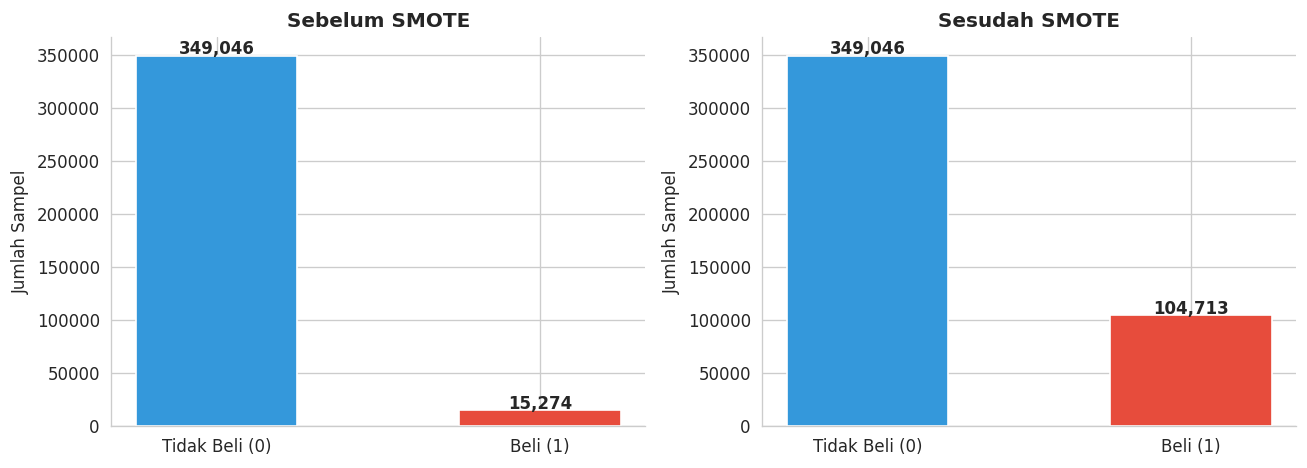

In [13]:
# ── 3.4 SMOTE — Handle Class Imbalance ──
print("Sebelum SMOTE:")
print(f"  Class 0 (tidak beli) : {(y_train==0).sum():,}")
print(f"  Class 1 (beli)       : {(y_train==1).sum():,}")
print(f"  Rasio                : {(y_train==0).sum()/(y_train==1).sum():.1f}:1")

smote = SMOTE(random_state=42, sampling_strategy=0.3, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print()
print("Sesudah SMOTE (sampling_strategy=0.3):")
print(f"  Class 0 (tidak beli) : {(y_train_res==0).sum():,}")
print(f"  Class 1 (beli)       : {(y_train_res==1).sum():,}")
print(f"  Rasio                : {(y_train_res==0).sum()/(y_train_res==1).sum():.1f}:1")

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, counts, title in zip(
    axes,
    [y_train.value_counts(), pd.Series(y_train_res).value_counts()],
    ['Sebelum SMOTE', 'Sesudah SMOTE']
):
    bars = ax.bar(['Tidak Beli (0)', 'Beli (1)'], counts.sort_index().values,
                  color=['#3498DB','#E74C3C'], edgecolor='white', width=0.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Jumlah Sampel')
    for bar, v in zip(bars, counts.sort_index().values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                f'{v:,}', ha='center', fontweight='bold', fontsize=10)
    ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('plot_smote_comparison.png', bbox_inches='tight', dpi=150)
plt.show()


## 4. 🤖 Model Training & Comparison

In [14]:
# ── 4.1 Definisi Model ──
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_val_scaled   = scaler.transform(X_val)

models = {
    'Logistic Regression': LogisticRegression(
        C=1.0, max_iter=1000, random_state=42, class_weight='balanced'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=12, min_samples_leaf=5,
        class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=5, random_state=42,
        eval_metric='logloss', verbosity=0
    )
}

print("✅ Model yang akan dibandingkan:")
for name in models:
    print(f"   • {name}")


✅ Model yang akan dibandingkan:
   • Logistic Regression
   • Random Forest
   • XGBoost


In [15]:
# ── 4.2 Training & Evaluasi Semua Model ──
results = {}
trained_models = {}

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Training: {name}")
    print('='*50)

    # Gunakan scaled data untuk LR, raw untuk RF & XGB
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train_res)
        y_proba = model.predict_proba(X_val_scaled)[:, 1]
        y_pred  = model.predict(X_val_scaled)
    else:
        model.fit(X_train_res, y_train_res)
        y_proba = model.predict_proba(X_val)[:, 1]
        y_pred  = model.predict(X_val)

    roc_auc   = roc_auc_score(y_val, y_proba)
    ap        = average_precision_score(y_val, y_proba)
    f1        = f1_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred)
    recall    = recall_score(y_val, y_pred)

    results[name] = {
        'ROC-AUC'   : roc_auc,
        'Avg Precision': ap,
        'F1-Score'  : f1,
        'Precision' : precision,
        'Recall'    : recall,
        'y_proba'   : y_proba,
        'y_pred'    : y_pred
    }
    trained_models[name] = model

    print(f"  ROC-AUC           : {roc_auc:.4f}")
    print(f"  Average Precision : {ap:.4f}")
    print(f"  F1-Score          : {f1:.4f}")
    print(f"  Precision         : {precision:.4f}")
    print(f"  Recall            : {recall:.4f}")
    print()
    print(classification_report(y_val, y_pred, target_names=['Tidak Beli','Beli']))



Training: Logistic Regression
  ROC-AUC           : 0.9973
  Average Precision : 0.9001
  F1-Score          : 0.9230
  Precision         : 0.8641
  Recall            : 0.9906

              precision    recall  f1-score   support

  Tidak Beli       1.00      0.99      1.00     87262
        Beli       0.86      0.99      0.92      3819

    accuracy                           0.99     91081
   macro avg       0.93      0.99      0.96     91081
weighted avg       0.99      0.99      0.99     91081


Training: Random Forest
  ROC-AUC           : 0.9974
  Average Precision : 0.8983
  F1-Score          : 0.9107
  Precision         : 0.8424
  Recall            : 0.9911

              precision    recall  f1-score   support

  Tidak Beli       1.00      0.99      1.00     87262
        Beli       0.84      0.99      0.91      3819

    accuracy                           0.99     91081
   macro avg       0.92      0.99      0.95     91081
weighted avg       0.99      0.99      0.99     91081

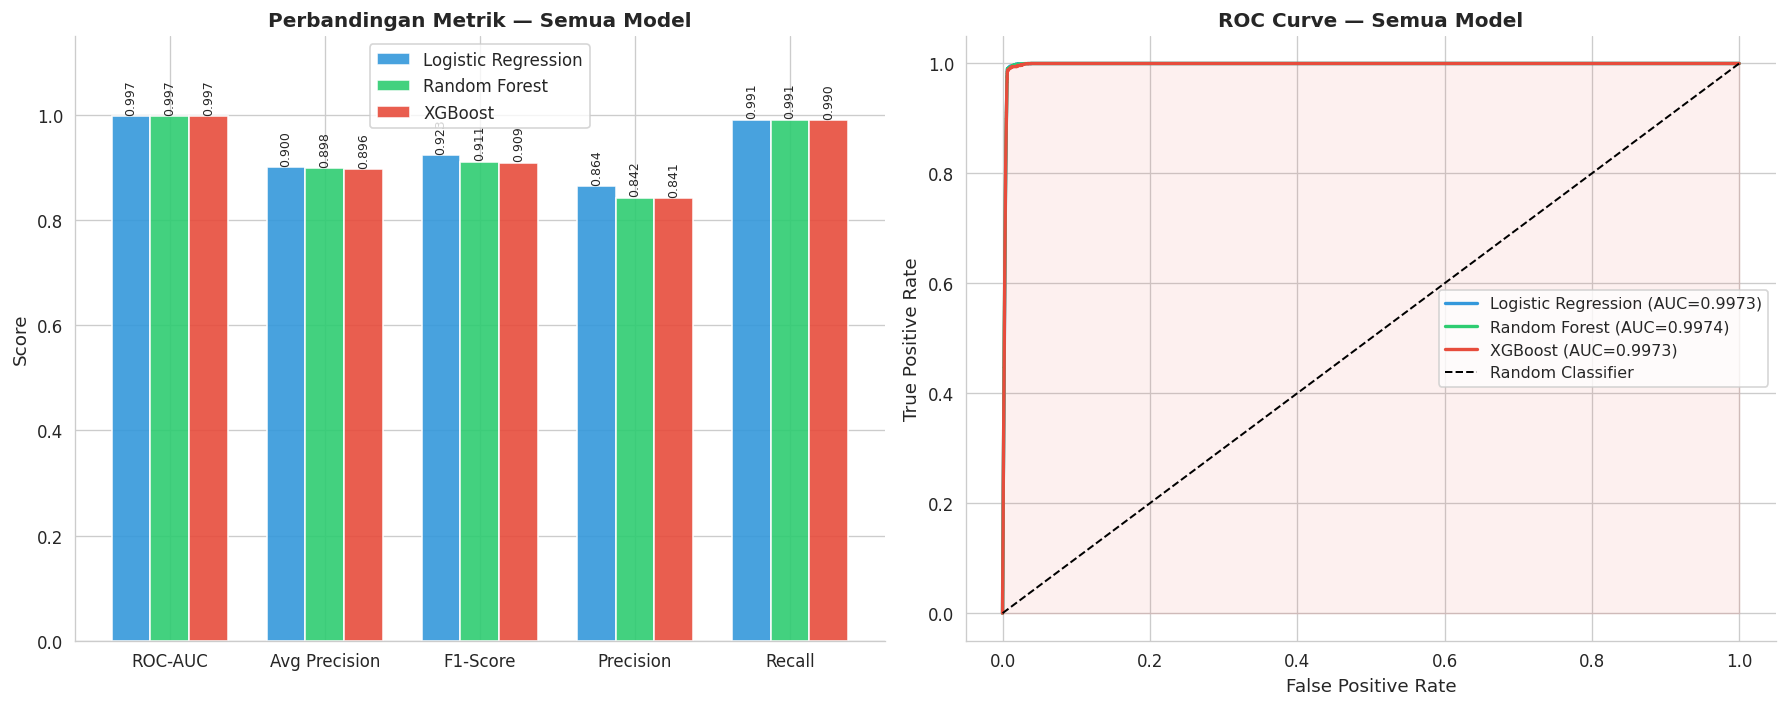

In [16]:
# ── 4.3 Perbandingan Metrik Semua Model ──
metric_names = ['ROC-AUC', 'Avg Precision', 'F1-Score', 'Precision', 'Recall']
model_names  = list(results.keys())
colors_m     = ['#3498DB', '#2ECC71', '#E74C3C']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Bar chart perbandingan
x     = np.arange(len(metric_names))
width = 0.25
for i, (mname, color) in enumerate(zip(model_names, colors_m)):
    vals = [results[mname][m] for m in metric_names]
    bars = axes[0].bar(x + i*width, vals, width, label=mname, color=color, edgecolor='white', alpha=0.9)
    for bar, v in zip(bars, vals):
        axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                     f'{v:.3f}', ha='center', va='bottom', fontsize=7.5, rotation=90)

axes[0].set_xticks(x + width)
axes[0].set_xticklabels(metric_names, fontsize=10)
axes[0].set_ylim(0, 1.15)
axes[0].set_ylabel('Score', fontsize=11)
axes[0].set_title('Perbandingan Metrik — Semua Model', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].spines[['top','right']].set_visible(False)

# ROC Curve
for mname, color in zip(model_names, colors_m):
    fpr, tpr, _ = roc_curve(y_val, results[mname]['y_proba'])
    auc = results[mname]['ROC-AUC']
    axes[1].plot(fpr, tpr, color=color, lw=2, label=f'{mname} (AUC={auc:.4f})')
axes[1].plot([0,1],[0,1],'k--', lw=1.2, label='Random Classifier')
axes[1].fill_between(*roc_curve(y_val, results['XGBoost']['y_proba'])[:2], alpha=0.08, color='#E74C3C')
axes[1].set_xlabel('False Positive Rate', fontsize=11)
axes[1].set_ylabel('True Positive Rate', fontsize=11)
axes[1].set_title('ROC Curve — Semua Model', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9.5)
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('plot_model_comparison.png', bbox_inches='tight', dpi=150)
plt.show()


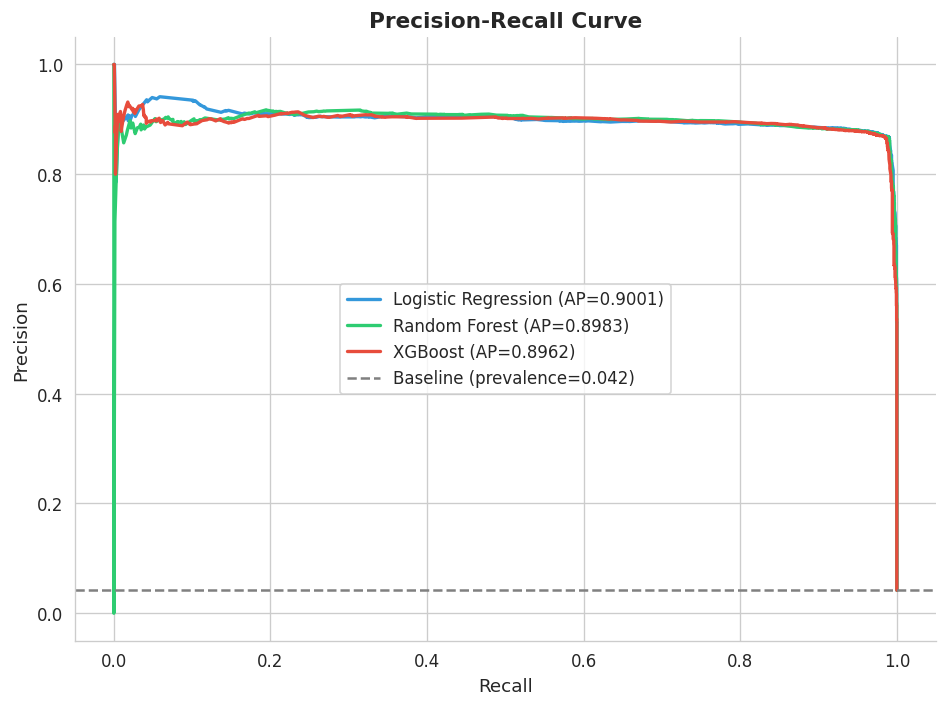

In [17]:
# ── 4.4 Precision-Recall Curve ──
fig, ax = plt.subplots(figsize=(8, 6))

for mname, color in zip(model_names, colors_m):
    prec, rec, _ = precision_recall_curve(y_val, results[mname]['y_proba'])
    ap = results[mname]['Avg Precision']
    ax.plot(rec, prec, color=color, lw=2, label=f'{mname} (AP={ap:.4f})')

baseline = y_val.mean()
ax.axhline(baseline, color='gray', linestyle='--', lw=1.5,
           label=f'Baseline (prevalence={baseline:.3f})')
ax.set_xlabel('Recall', fontsize=11)
ax.set_ylabel('Precision', fontsize=11)
ax.set_title('Precision-Recall Curve', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('plot_precision_recall.png', bbox_inches='tight', dpi=150)
plt.show()


🏆 Best Model: Random Forest (ROC-AUC: 0.9974)


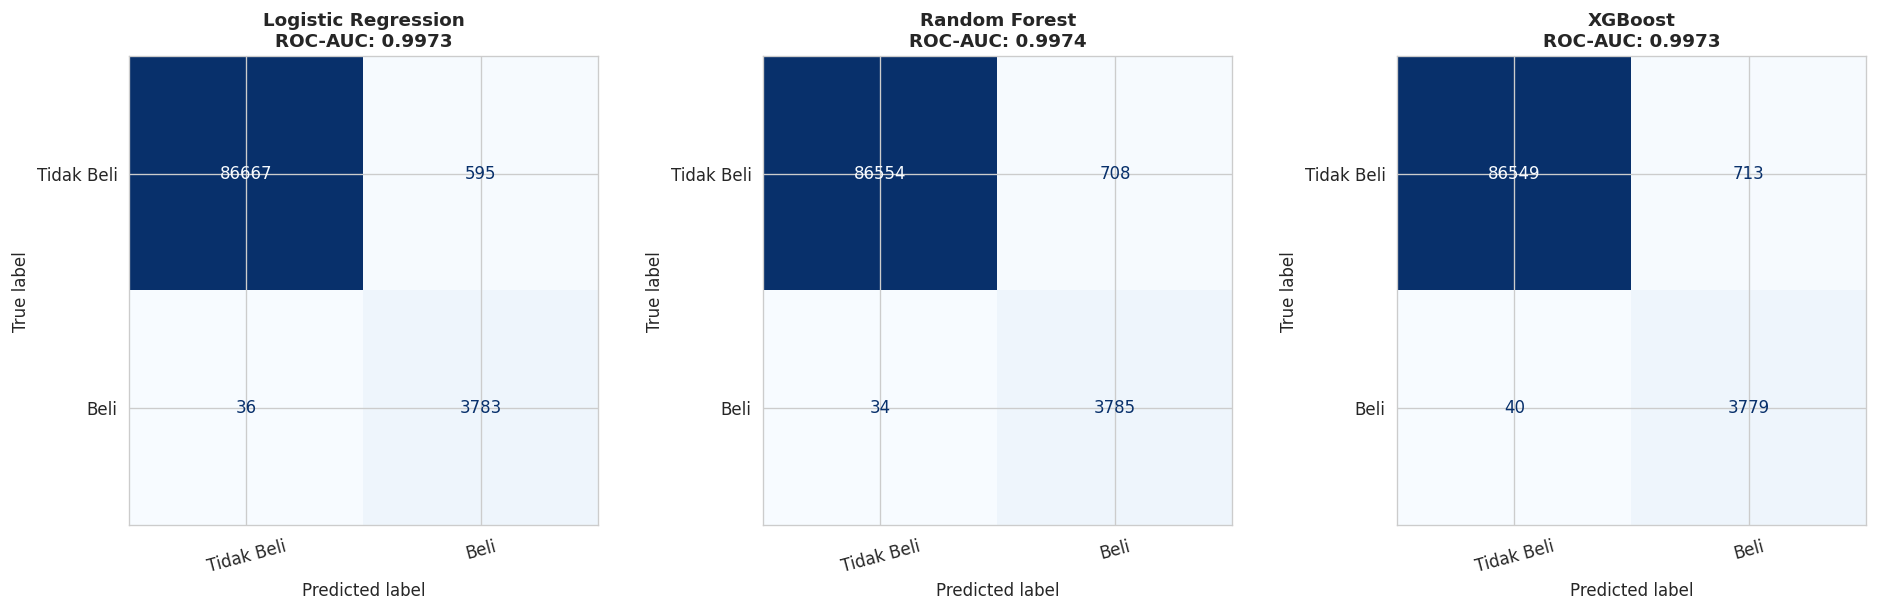

In [18]:
# ── 4.5 Confusion Matrix — Best Model (XGBoost) ──
best_model_name = max(results, key=lambda k: results[k]['ROC-AUC'])
print(f"🏆 Best Model: {best_model_name} (ROC-AUC: {results[best_model_name]['ROC-AUC']:.4f})")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (mname, color) in zip(axes, zip(model_names, colors_m)):
    cm = confusion_matrix(y_val, results[mname]['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Tidak Beli','Beli'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{mname}\nROC-AUC: {results[mname]["ROC-AUC"]:.4f}',
                 fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', labelrotation=15)

plt.tight_layout()
plt.savefig('plot_confusion_matrices.png', bbox_inches='tight', dpi=150)
plt.show()


## 5. 📊 Feature Importance

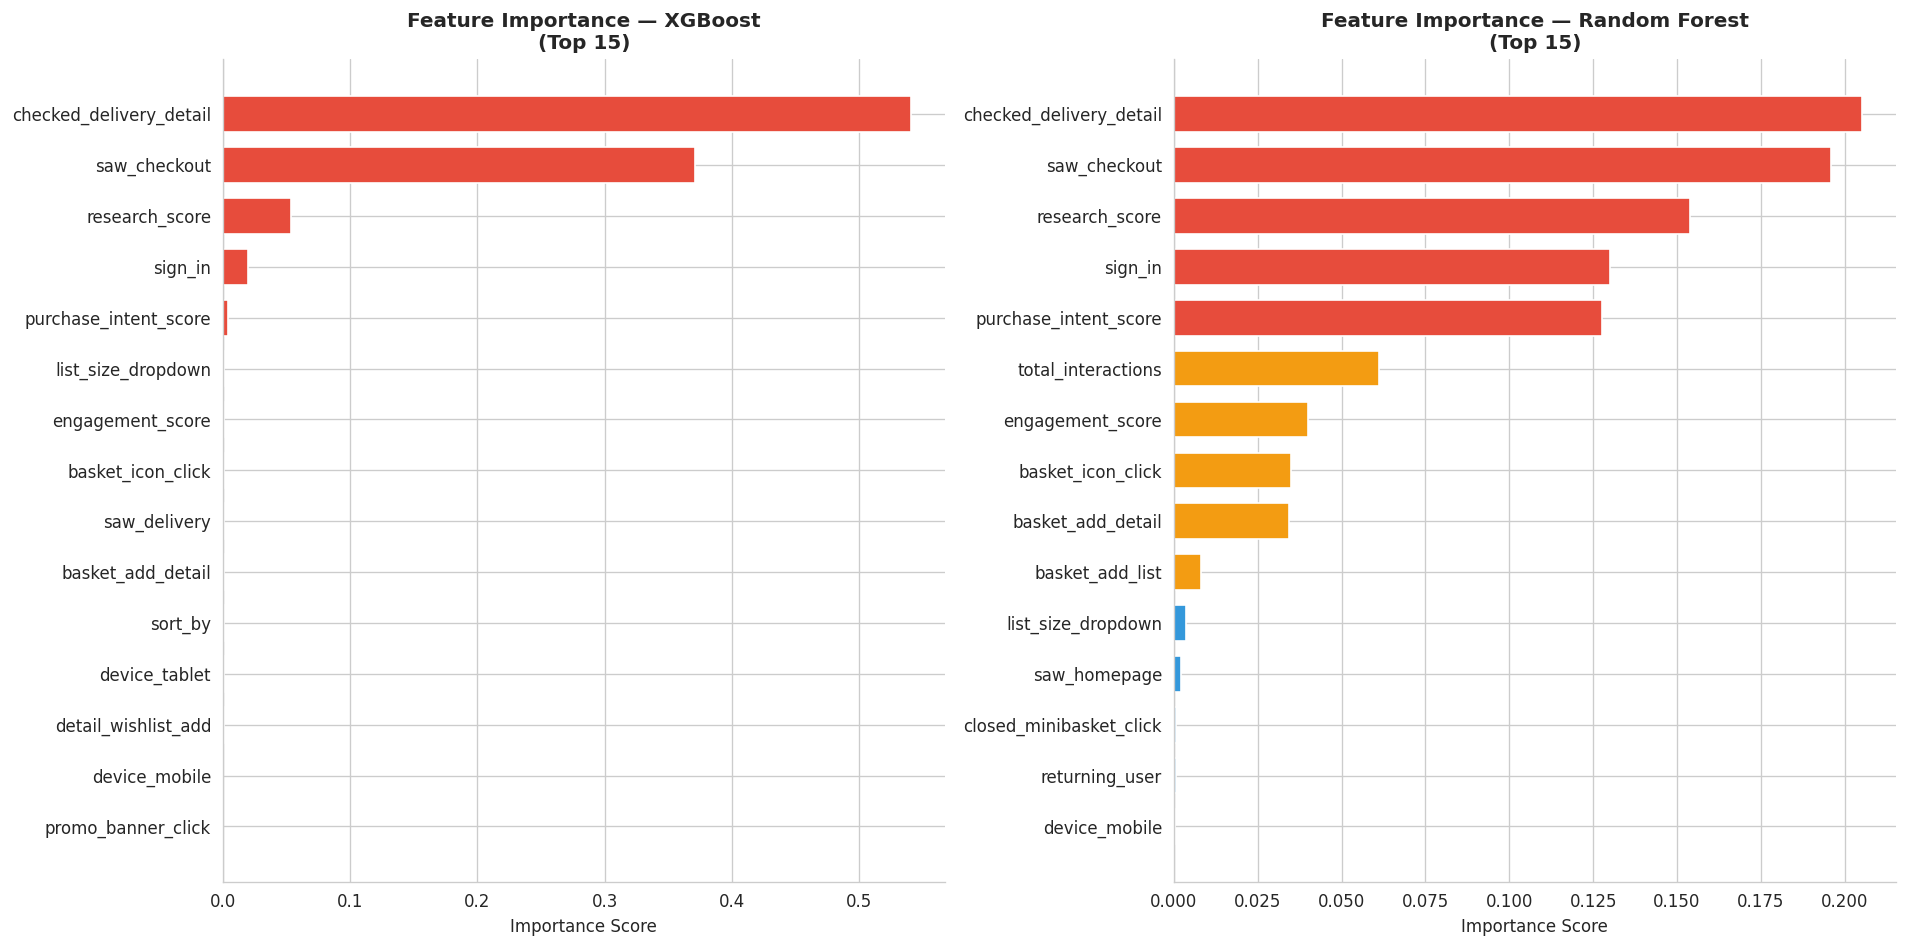

Top 10 Fitur — XGBoost:
checked_delivery_detail    0.540401
saw_checkout               0.370622
research_score             0.053975
sign_in                    0.019802
purchase_intent_score      0.003803
list_size_dropdown         0.001248
engagement_score           0.000903
basket_icon_click          0.000811
saw_delivery               0.000674
basket_add_detail          0.000655


In [19]:
# ── 5.1 XGBoost Feature Importance ──
best_xgb  = trained_models['XGBoost']
best_rf   = trained_models['Random Forest']

fi_xgb = pd.Series(best_xgb.feature_importances_, index=feature_cols_eng).sort_values(ascending=False)
fi_rf  = pd.Series(best_rf.feature_importances_,  index=feature_cols_eng).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# XGBoost
top_n = 15
colors_fi = ['#E74C3C' if i < 5 else '#F39C12' if i < 10 else '#3498DB'
             for i in range(top_n)]
axes[0].barh(fi_xgb.head(top_n).index[::-1], fi_xgb.head(top_n).values[::-1],
             color=colors_fi[::-1], edgecolor='white', height=0.7)
axes[0].set_title(f'Feature Importance — XGBoost\n(Top {top_n})',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Importance Score', fontsize=10)
axes[0].spines[['top','right']].set_visible(False)

# Random Forest
axes[1].barh(fi_rf.head(top_n).index[::-1], fi_rf.head(top_n).values[::-1],
             color=colors_fi[::-1], edgecolor='white', height=0.7)
axes[1].set_title(f'Feature Importance — Random Forest\n(Top {top_n})',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Importance Score', fontsize=10)
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('plot_feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()

print("Top 10 Fitur — XGBoost:")
print(fi_xgb.head(10).to_string())


## 6. 💾 Final Model — Save Artifacts

In [20]:
# ── 6.1 Retrain Best Model pada Full Training Data ──
print("Retraining XGBoost pada full training data (X_eng)...")

# Full SMOTE pada seluruh training data
smote_full = SMOTE(random_state=42, sampling_strategy=0.3, k_neighbors=5)
X_full_res, y_full_res = smote_full.fit_resample(X_eng, y)

# Scaler untuk seluruh data (dipakai LR, disimpan untuk Streamlit)
scaler_full = StandardScaler()
scaler_full.fit(X_full_res)

# Final XGBoost
final_model = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=5, random_state=42,
    eval_metric='logloss', verbosity=0
)
final_model.fit(X_full_res, y_full_res)
print("✅ Final model selesai ditraining!")

# Validasi ulang pada validation set
y_final_proba_val = final_model.predict_proba(X_val)[:, 1]
print(f"Validasi ROC-AUC (val set): {roc_auc_score(y_val, y_final_proba_val):.4f}")


Retraining XGBoost pada full training data (X_eng)...
✅ Final model selesai ditraining!
Validasi ROC-AUC (val set): 0.9977


In [21]:
# ── 6.2 Save Model & Scaler ke Pickle ──
import pickle

artifacts = {
    'model'        : final_model,
    'scaler'       : scaler_full,
    'feature_cols' : feature_cols_eng,
    'model_name'   : 'XGBoost',
    'metrics'      : {k: v for k, v in results['XGBoost'].items()
                      if k not in ['y_proba','y_pred']}
}

with open('model_propensity.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

print("✅ Saved: model_propensity.pkl")
print(f"   Model         : XGBoost")
print(f"   Features used : {len(feature_cols_eng)}")
print(f"   File size     : {os.path.getsize('model_propensity.pkl') / 1024:.1f} KB")


✅ Saved: model_propensity.pkl
   Model         : XGBoost
   Features used : 27
   File size     : 970.4 KB


In [22]:
# ── 6.3 Prediksi pada Testing Set & Save CSV ──
def add_engineered_features(df):
    df = df.copy()
    df['purchase_intent_score'] = (
        df['basket_add_detail'] + df['basket_add_list'] +
        df['saw_checkout'] + df['basket_icon_click'] + df['sign_in']
    )
    df['engagement_score'] = (
        df['list_size_dropdown'] + df['checked_delivery_detail'] +
        df['image_picker'] + df['sort_by'] + df['promo_banner_click']
    )
    df['research_score'] = (
        df['detail_wishlist_add'] + df['checked_delivery_detail'] +
        df['checked_returns_detail'] + df['saw_sizecharts'] + df['saw_delivery']
    )
    base_cols = [c for c in df.columns if c not in
                 ['purchase_intent_score','engagement_score','research_score']]
    binary_feature_cols = [c for c in base_cols if df[c].isin([0,1]).all()]
    df['total_interactions'] = df[binary_feature_cols].sum(axis=1)
    return df

X_te_eng_final = add_engineered_features(test_df[feature_cols])
y_test_proba   = final_model.predict_proba(X_te_eng_final[feature_cols_eng])[:, 1]
y_test_pred    = (y_test_proba >= 0.5).astype(int)

result_df = test_df[['UserID']].copy()
result_df['predicted_ordered']    = y_test_pred
result_df['purchase_probability'] = y_test_proba.round(4)
result_df['propensity_segment']   = pd.cut(
    y_test_proba,
    bins=[0, 0.2, 0.5, 0.75, 1.0],
    labels=['Low', 'Medium', 'High', 'Very High']
)

result_df.to_csv('hasil_prediksi_testing.csv', index=False)

print("✅ Saved: hasil_prediksi_testing.csv")
print(f"   Total prediksi       : {len(result_df):,}")
print(f"   Prediksi Beli (1)    : {y_test_pred.sum():,} ({y_test_pred.mean()*100:.2f}%)")
print(f"   Prediksi Tdk Beli(0) : {(y_test_pred==0).sum():,}")
print()
print("Distribusi Propensity Segment:")
print(result_df['propensity_segment'].value_counts().to_string())
result_df.head(10)


✅ Saved: hasil_prediksi_testing.csv
   Total prediksi       : 151,655
   Prediksi Beli (1)    : 1,598 (1.05%)
   Prediksi Tdk Beli(0) : 150,057

Distribusi Propensity Segment:
propensity_segment
Low          149411
Very High      1162
Medium          646
High            436


,UserID,predicted_ordered,purchase_probability,propensity_segment
0,9d24-25k4-47889d24-25k4-494b-398124,0,0.0000,Low
1,7732-1k58-47887732-1k58-4475-679678,0,0.0000,Low
2,94k2-632j-471394k2-632j-4b4j-228160,0,0.0000,Low
3,jdd8-419d-4714jdd8-419d-4198-674376,0,0.0000,Low
4,7473-7595-47147473-7595-4757-227547,0,0.0000,Low
5,7j3d-j382-47157j3d-j382-4d3b-955343,1,0.9066,Very High
6,bb4d-8019-4715bb4d-8019-4d42-763898,0,0.0000,Low
7,d09k-j446-4716d09k-j446-4469-572703,0,0.0000,Low
8,1397-7143-47171397-7143-4969-95351,0,0.0000,Low
9,3j36-dj4d-47183j36-dj4d-4478-404497,0,0.0000,Low


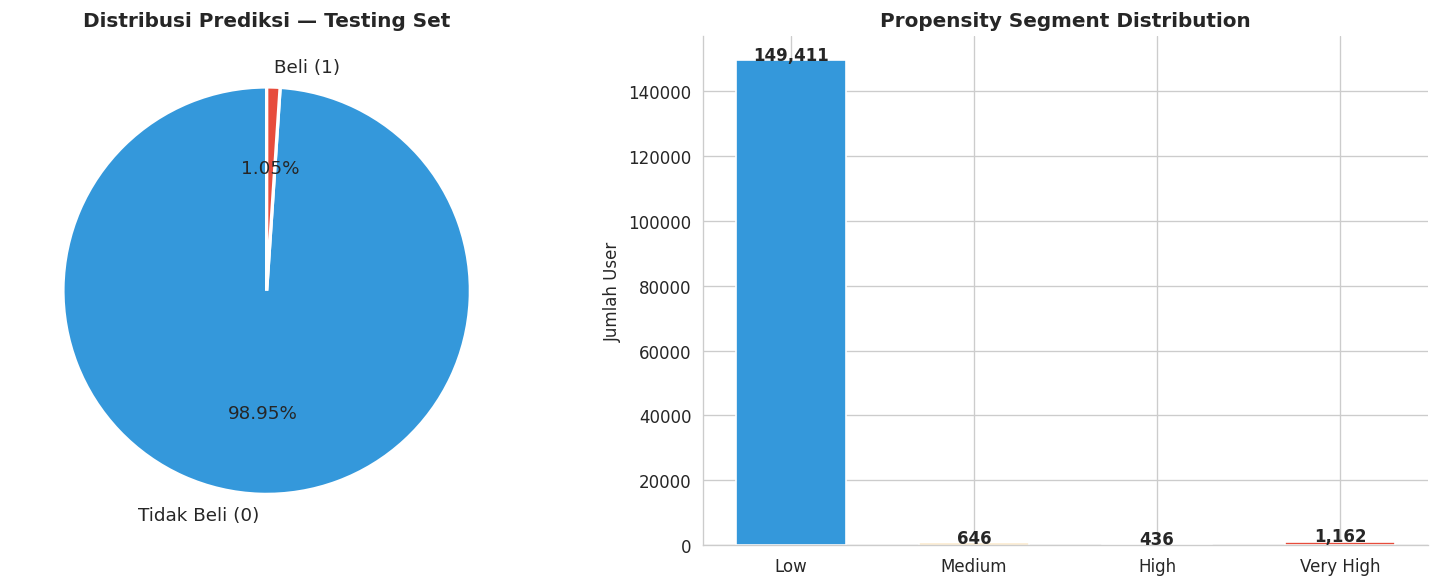

In [23]:
# ── 6.4 Visualisasi Hasil Prediksi ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pie — prediksi
pred_counts = result_df['predicted_ordered'].value_counts()
axes[0].pie(pred_counts.values, labels=['Tidak Beli (0)', 'Beli (1)'],
            colors=['#3498DB','#E74C3C'], autopct='%1.2f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2),
            textprops={'fontsize': 11})
axes[0].set_title('Distribusi Prediksi — Testing Set', fontsize=12, fontweight='bold')

# Bar — segmen
seg_counts = result_df['propensity_segment'].value_counts().reindex(['Low','Medium','High','Very High'])
seg_colors = ['#3498DB','#F39C12','#E67E22','#E74C3C']
bars = axes[1].bar(seg_counts.index, seg_counts.values, color=seg_colors, edgecolor='white', width=0.6)
axes[1].set_title('Propensity Segment Distribution', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Jumlah User')
axes[1].spines[['top','right']].set_visible(False)
for bar, v in zip(bars, seg_counts.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+100,
                 f'{v:,}', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('plot_prediction_results.png', bbox_inches='tight', dpi=150)
plt.show()


## 7. 📋 Summary & Kesimpulan

In [24]:
# ── 7. Summary ──
print("=" * 60)
print("       RINGKASAN HASIL — CUSTOMER PROPENSITY MODEL")
print("=" * 60)

print("\n📊 DATASET:")
print(f"   Training : {len(train_df):,} baris | Testing : {len(test_df):,} baris")
print(f"   Fitur    : {len(feature_cols_eng)} (23 original + 4 engineered)")
print(f"   Target   : ordered (imbalanced ~4.2% positif)")

print("\n🤖 MODEL COMPARISON:")
summary_data = []
for mname in model_names:
    r = results[mname]
    summary_data.append({
        'Model': mname,
        'ROC-AUC': f"{r['ROC-AUC']:.4f}",
        'F1-Score': f"{r['F1-Score']:.4f}",
        'Precision': f"{r['Precision']:.4f}",
        'Recall': f"{r['Recall']:.4f}"
    })
summary_df = pd.DataFrame(summary_data).set_index('Model')
print(summary_df.to_string())

print(f"\n🏆 BEST MODEL: XGBoost")
print(f"   ROC-AUC : {results['XGBoost']['ROC-AUC']:.4f}")
print(f"   F1-Score: {results['XGBoost']['F1-Score']:.4f}")

print("\n📁 OUTPUT FILES:")
output_files = [
    ('model_propensity.pkl',          'Final model + scaler + metadata'),
    ('hasil_prediksi_testing.csv',    'Prediksi testing set + probability + segment'),
    ('plot_target_distribution.png',  'Visualisasi distribusi target'),
    ('plot_feature_correlation.png',  'Korelasi fitur vs target'),
    ('plot_conversion_rate.png',      'Conversion rate per aksi'),
    ('plot_group_analysis.png',       'Analisis group (device, lokasi, user type)'),
    ('plot_heatmap_correlation.png',  'Heatmap korelasi fitur'),
    ('plot_smote_comparison.png',     'Sebelum vs sesudah SMOTE'),
    ('plot_model_comparison.png',     'Perbandingan metrik semua model'),
    ('plot_precision_recall.png',     'Precision-Recall curve'),
    ('plot_confusion_matrices.png',   'Confusion matrix semua model'),
    ('plot_feature_importance.png',   'Feature importance XGBoost & RF'),
    ('plot_prediction_results.png',   'Distribusi hasil prediksi testing'),
]
for fname, desc in output_files:
    status = '✅' if os.path.exists(fname) else '❌'
    print(f"   {status} {fname:<38} — {desc}")

print("\n✅ Pipeline selesai! Semua artifact tersimpan.")


       RINGKASAN HASIL — CUSTOMER PROPENSITY MODEL

📊 DATASET:
   Training : 455,401 baris | Testing : 151,655 baris
   Fitur    : 27 (23 original + 4 engineered)
   Target   : ordered (imbalanced ~4.2% positif)

🤖 MODEL COMPARISON:
                    ROC-AUC F1-Score Precision  Recall
Model                                                 
Logistic Regression  0.9973   0.9230    0.8641  0.9906
Random Forest        0.9974   0.9107    0.8424  0.9911
XGBoost              0.9973   0.9094    0.8413  0.9895

🏆 BEST MODEL: XGBoost
   ROC-AUC : 0.9973
   F1-Score: 0.9094

📁 OUTPUT FILES:
   ✅ model_propensity.pkl                   — Final model + scaler + metadata
   ✅ hasil_prediksi_testing.csv             — Prediksi testing set + probability + segment
   ✅ plot_target_distribution.png           — Visualisasi distribusi target
   ✅ plot_feature_correlation.png           — Korelasi fitur vs target
   ✅ plot_conversion_rate.png               — Conversion rate per aksi
   ✅ plot_group_analysis.